In [ ]:
from trastuzumab.pinns import Pinn, get_spatial_antibody_distribution
from pathlib import Path
models_dir = Path.cwd().parent/'models'
pinn = Pinn.load(models_dir/'benchmark_pinn.pt')
get_spatial_antibody_distribution(1.0, pinn, 1.0)

In [ ]:
import torch
from trastuzumab.pinns import Pinn, get_spatial_antibody_distribution

# // hyperparameters.
_L = 1060 / 1060
_T = 1.0 / 24 
# //
DEVICE = 'cpu'
# //
NUM_COLLOC = 4000
NUM_INITIAL = 300
NUM_CENTER = 300
NUM_SURFACE = 300
# //
ADAM_EPOCHS = 10000
LBFGS_EPOCHS = 2000
# //
benchmark_pinn = Pinn(NUM_COLLOC, NUM_INITIAL, NUM_CENTER, NUM_SURFACE, layers=3, neurons=64, device=DEVICE, u_bounds=[1, _T])

optimizer = torch.optim.Adam(params=benchmark_pinn.net.parameters(), lr=0.001)
benchmark_pinn.train_adam(epochs=10000, optimizer=optimizer, L=_L)
get_spatial_antibody_distribution(t_exp = _T, pinn=benchmark_pinn, L=_L)

In [ ]:
benchmark_pinn.train_adam(epochs=10000, optimizer=optimizer, L=_L)
get_spatial_antibody_distribution(t_exp = _T, pinn=benchmark_pinn, L=_L)

In [ ]:
from pathlib import Path
models_path = Path.cwd().parent/'models'
benchmark_pinn.save(models_path/'benchmark_pinn.pt')

In [ ]:
def greedy_training(from_t, to_t, step, pinn: Pinn, _L):
    for ti in range(from_t, to_t, step):
        NEW_T = ti/24
        NUM_COLLOC = 4000 + int(NEW_T*24) * 200
        NUM_INITIAL = 300 + int(NEW_T*24) * 20
        NUM_CENTER = 300 + int(NEW_T*24) * 20
        NUM_SURFACE = 300 + int(NEW_T*24) * 20
        pinn.resample_datasets(NUM_COLLOC, NUM_INITIAL, NUM_CENTER, NUM_SURFACE, upper_bounds=[1, NEW_T])
        pinn.DATASET.plotme()
        pinn.train_adam(epochs=10000, optimizer=optimizer, L=_L)
        get_spatial_antibody_distribution(t_exp = NEW_T, pinn=pinn, L=_L)

In [ ]:
greedy_training(2, 25, 4, benchmark_pinn, 1.0)

In [ ]:
for ti in range(1, 25):
    NEW_T = ti/24
    NUM_COLLOC = 2000 + int(NEW_T*24) * 200
    NUM_INITIAL = 200 + int(NEW_T*24) * 20
    NUM_CENTER = 200 + int(NEW_T*24) * 20
    NUM_SURFACE = 200 + int(NEW_T*24) * 20

    time_marching_pinn.resample_datasets(NUM_COLLOC, NUM_INITIAL, NUM_CENTER, NUM_SURFACE, upper_bounds=[1, NEW_T])
    time_marching_pinn.DATASET.plotme()
    time_marching_pinn.train_adam(epochs=7000, optimizer=optimizer, L=0.5)
    get_spatial_antibody_distribution(t_exp = NEW_T, pinn=time_marching_pinn, L=.5)

In [ ]:
from pathlib import Path
time_marching_pinn.save(Path.cwd().parent / 'models/time_marching_v01.pt')

In [ ]:
## brute force pinn

import torch
from trastuzumab.pinns import Pinn, get_spatial_antibody_distribution
SIMULATION_HOURS = 24


# // hyperparameters.
T = SIMULATION_HOURS / 24
# //
DEVICE = 'cpu'
# //
NUM_COLLOC = 2000
NUM_INITIAL = 200
NUM_CENTER = 200
NUM_SURFACE = 200
# //
ADAM_EPOCHS = 10000
LBFGS_EPOCHS = 2000
# //
brute_force = Pinn(NUM_COLLOC, NUM_INITIAL, NUM_CENTER, NUM_SURFACE, layers=3, neurons=64, device=DEVICE, u_bounds=[1, T])
# forward_pinn.DATASET.plotme()

LAMBDA = 1060 / 1060
optimizer = torch.optim.Adam(brute_force.net.parameters(), 0.001)
brute_force.train_adam(epochs=10000, optimizer=optimizer, L=LAMBDA)
get_spatial_antibody_distribution(t_exp=24/24, pinn=brute_force, L=LAMBDA)

In [ ]:
brute_force.train_adam(epochs=10000, optimizer=optimizer, network_lr=0.001)
get_spatial_antibody_distribution(t_exp=24/24, pinn=brute_force, L=LAMBDA)

In [ ]:
get_spatial_antibody_distribution(t_exp=24/24, pinn=brute_force, L=LAMBDA)

In [ ]:
brute_force.train_adam(epochs=10000, optimizer=optimizer, network_lr=0.0001)
get_spatial_antibody_distribution(t_exp=24/24, pinn=brute_force, L=LAMBDA)

In [ ]:
from pathlib import Path

brute_force.save(Path.cwd().parent/'models/brute_force_modelv02.pt')

In [ ]:
## save/load...

from trastuzumab import evaluation, fdm
from trastuzumab.pinns import Pinn
import numpy as np
import pathlib

models_dir = pathlib.Path.cwd().parent/'models'

m=100
x, sol = fdm.run_fdm(m=m, phase_name='uptake', y0=np.zeros(3*(m+1)), t_final=1.0)
ev = evaluation.Evaluator(fdm_x=x, fdm_sol=sol.sol, n_t=101)

models = {
    'icc_pinn': Pinn.load(models_dir / 'icc_pinn.pt'),
}

results = ev.compare(models)
for label, r in results.items():
    print(f"{label:14s}  global={r['global_l2']:.3e}  per_species={ {k: f'{v:.2e}' for k,v in r['per_species'].items()} }")

In [ ]:
from trastuzumab.utils.plotting import plot_comparison
plot_comparison(results, ev, models)

In [ ]:
from pathlib import Path
from trastuzumab import neural_nets

state = torch.load(Path.cwd().parent/'models/icc_pinn.pt')
state['state_dict']

net = neural_nets.FCNN(3, 64)
net.load_state_dict(state['state_dict'])
net

neural network weights initialized succesfully


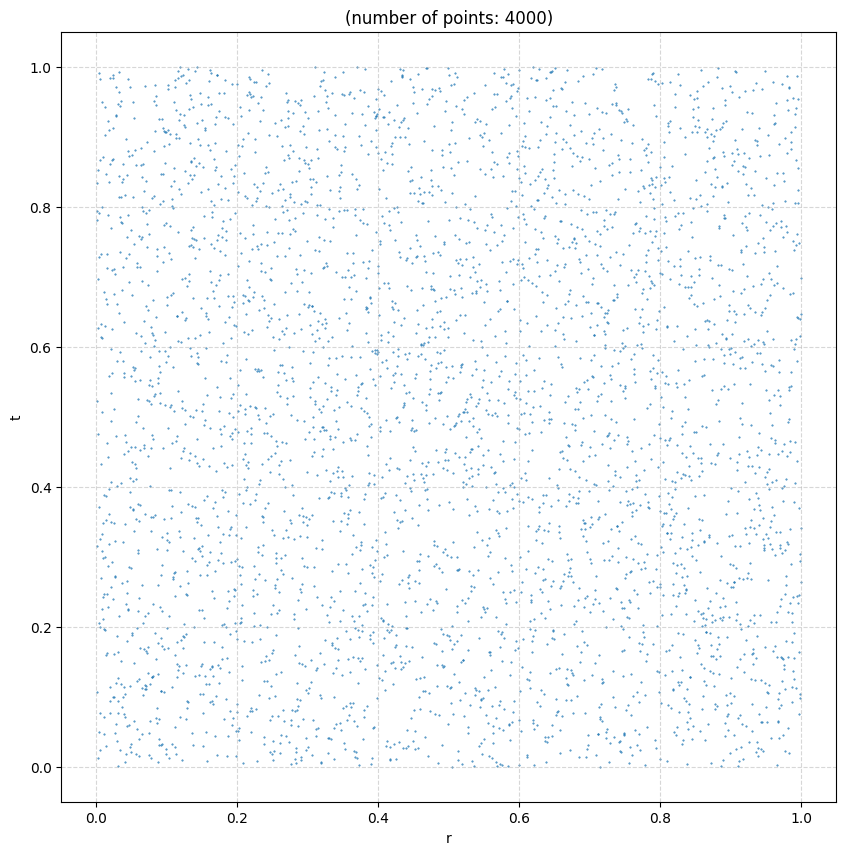

Adam Training started...
- Epochs: 20000
- R_T: 1060.00
- domain upper bounds[1, 1]
--------------------------------------------------------------------------------------------------------------------------------
  Epoch    |   Total    |   pde_0    |   pde_1    |   pde_2    |    bc0     |    bcR     |    ic_0    |    ic_1    |    ic_2    
--------------------------------------------------------------------------------------------------------------------------------
    0      | 1.8360e+05 | 2.3406e+04 | 1.5943e+05 | 1.2519e-05 | 1.6851e-03 | 7.5770e+02 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00


KeyboardInterrupt: 

In [1]:
import torch

from trastuzumab import pinns, residuals, neural_nets, datasets, sampling

dummy_pinn = pinns.Pinn(n_col=4000, n_initial=200, n_center=200, n_surface=200, u_bounds=[1, 1], device='cpu', layers=3, neurons=64)
dummy_pinn.collocation_training_dataset.plotme()

optimizer = torch.optim.Adam(dummy_pinn.net.parameters(), 0.001)
sampler = datasets.DatasetSampler()

dummy_pinn.train_adam(optimizer=optimizer, epochs=20000)

for N in range(5):
    cand = sampler.sample_collocation_points(50000, u_bounds=[1, 1])
    scores = sampling._score(net=dummy_pinn.net, canditates=cand, L=1.0)

    selected = sampling._select(scores=scores, canditates=cand, m_add=500)
    selected.plotme()
    dummy_pinn.collocation_training_dataset += selected
    dummy_pinn.collocation_training_dataset.plotme()

    dummy_pinn.train_adam(optimizer=optimizer, epochs=10000)
    pinns.get_spatial_antibody_distribution(t_exp=1.0, pinn=dummy_pinn, L=1.0)


neural network weights initialized succesfully
Adam Training started...
- Epochs: 20000
- R_T: 1060.00
- domain upper bounds[1, 1]
--------------------------------------------------------------------------------------------------------------------------------
  Epoch    |   Total    |   pde_0    |   pde_1    |   pde_2    |    bc0     |    bcR     |    ic_0    |    ic_1    |    ic_2    
--------------------------------------------------------------------------------------------------------------------------------
    0      | 1.8342e+05 | 2.4485e+04 | 1.5818e+05 | 1.2420e-05 | 1.6851e-03 | 7.5770e+02 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   200     | 1.1305e+02 | 3.3698e+00 | 1.6693e+01 | 9.9996e-09 | 2.9366e-04 | 9.2987e+01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   400     | 1.1137e+02 | 2.9410e+00 | 1.4661e+01 | 8.2550e-09 | 2.6886e-04 | 9.3772e+01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   600     | 1.0975e+02 | 2.5339e+00 | 1.2658e+01 | 1.1364e-08 | 2.4110e-04 | 9.4560e+01 | 0.0000e

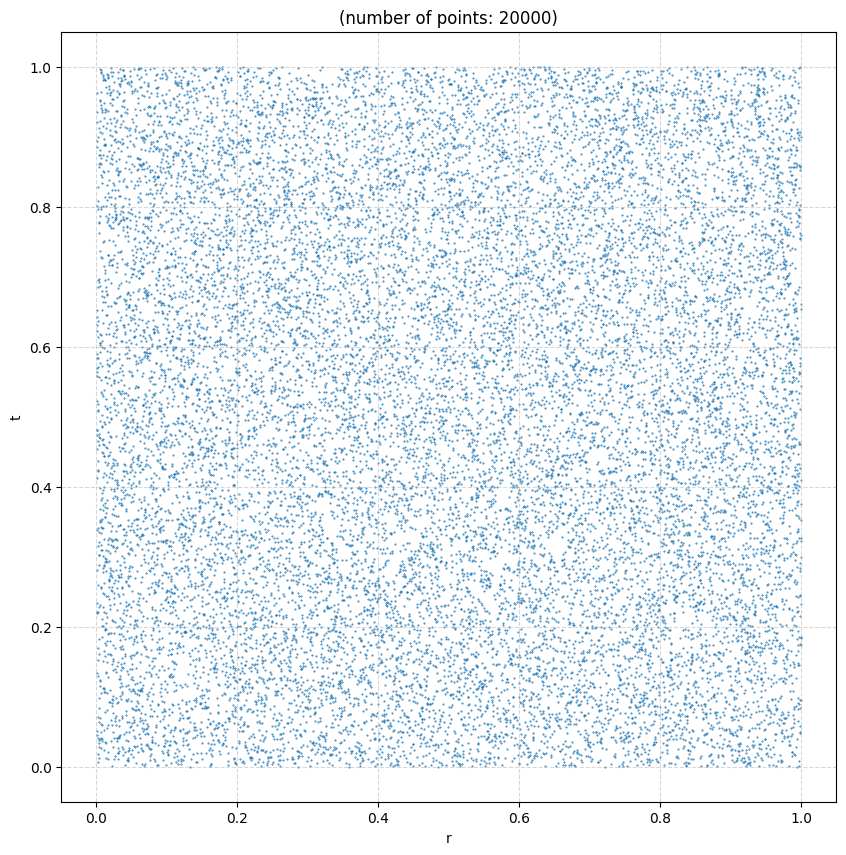

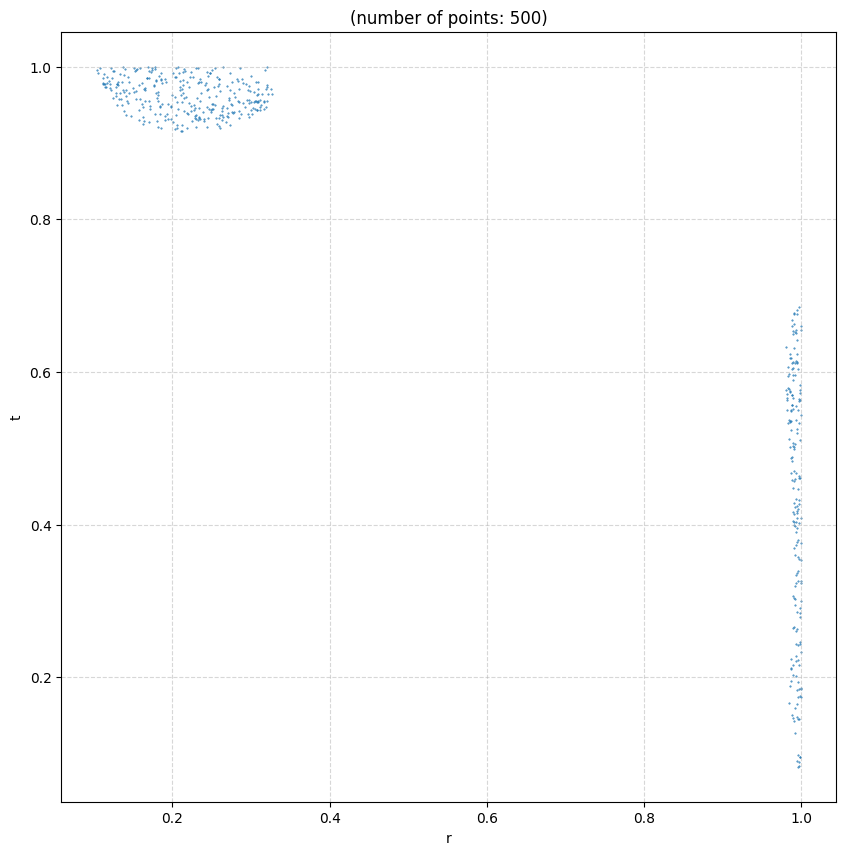

[RAR-G] round  1 | points= 2500 | max_res=2.703e+02 | mean_res=9.966e+01
Adam Training started...
- Epochs: 10000
- R_T: 1060.00
- domain upper boundsNone
--------------------------------------------------------------------------------------------------------------------------------
  Epoch    |   Total    |   pde_0    |   pde_1    |   pde_2    |    bc0     |    bcR     |    ic_0    |    ic_1    |    ic_2    
--------------------------------------------------------------------------------------------------------------------------------
    0      | 2.4175e+01 | 3.1351e+00 | 1.5273e+01 | 1.0044e-04 | 1.3417e-03 | 5.7658e+00 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   200     | 6.9436e+00 | 3.4972e-01 | 6.9875e-01 | 9.5554e-05 | 1.0135e-03 | 5.8940e+00 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   400     | 6.6921e+00 | 3.1019e-01 | 6.0587e-01 | 6.2870e-05 | 1.0294e-03 | 5.7750e+00 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   600     | 6.4995e+00 | 2.9021e-01 | 5.6701e-01 | 5.0882e-05 | 1.0734e-0

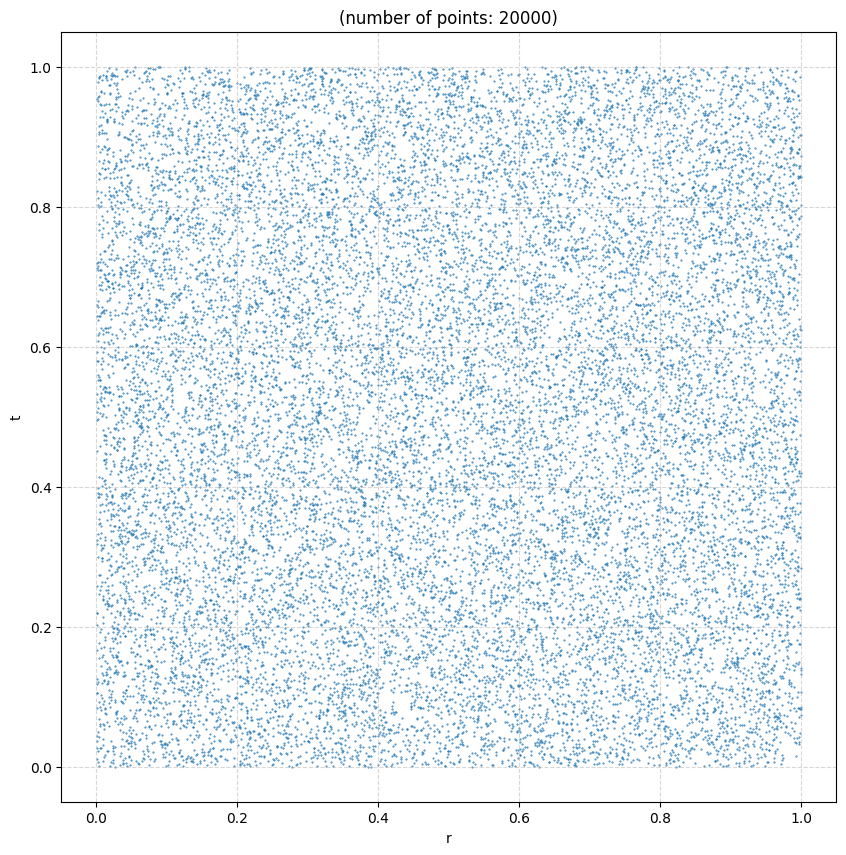

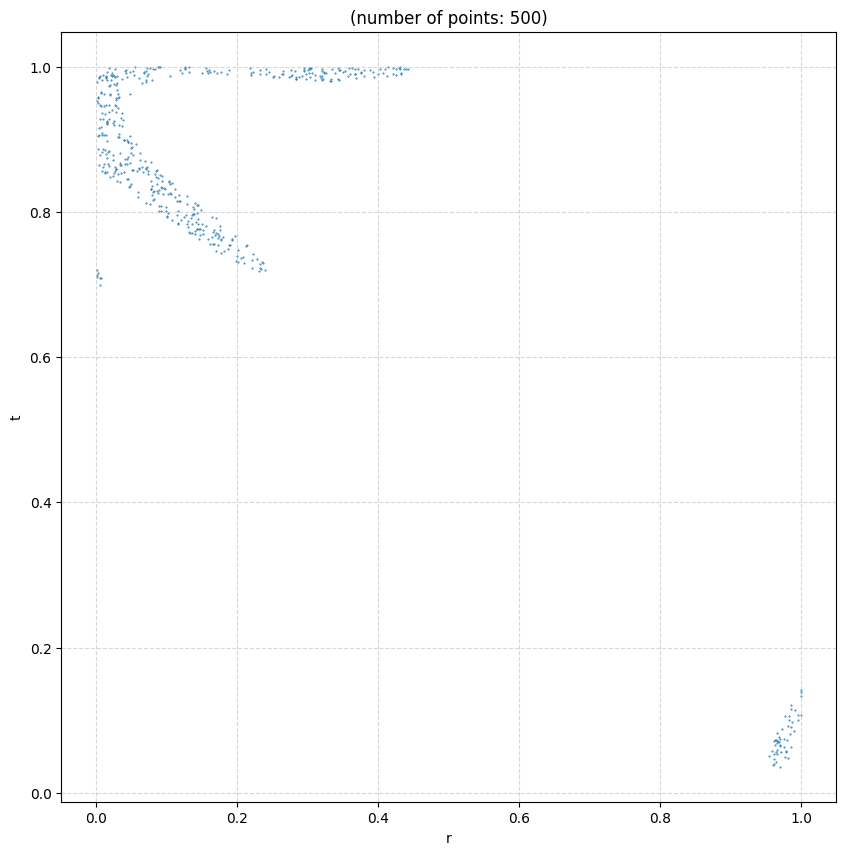

[RAR-G] round  2 | points= 3000 | max_res=6.817e+01 | mean_res=2.762e+01
Adam Training started...
- Epochs: 10000
- R_T: 1060.00
- domain upper boundsNone
--------------------------------------------------------------------------------------------------------------------------------
  Epoch    |   Total    |   pde_0    |   pde_1    |   pde_2    |    bc0     |    bcR     |    ic_0    |    ic_1    |    ic_2    
--------------------------------------------------------------------------------------------------------------------------------
    0      | 3.5948e+00 | 1.2110e-01 | 1.3790e+00 | 4.0459e-05 | 2.8337e-03 | 2.0917e+00 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   200     | 2.3519e+00 | 7.6599e-02 | 1.5951e-01 | 4.6777e-05 | 2.8017e-03 | 2.1130e+00 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   400     | 2.2846e+00 | 6.7163e-02 | 1.2721e-01 | 2.4983e-05 | 2.7983e-03 | 2.0874e+00 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   600     | 2.2485e+00 | 6.4398e-02 | 1.1719e-01 | 2.3016e-05 | 2.8309e-0

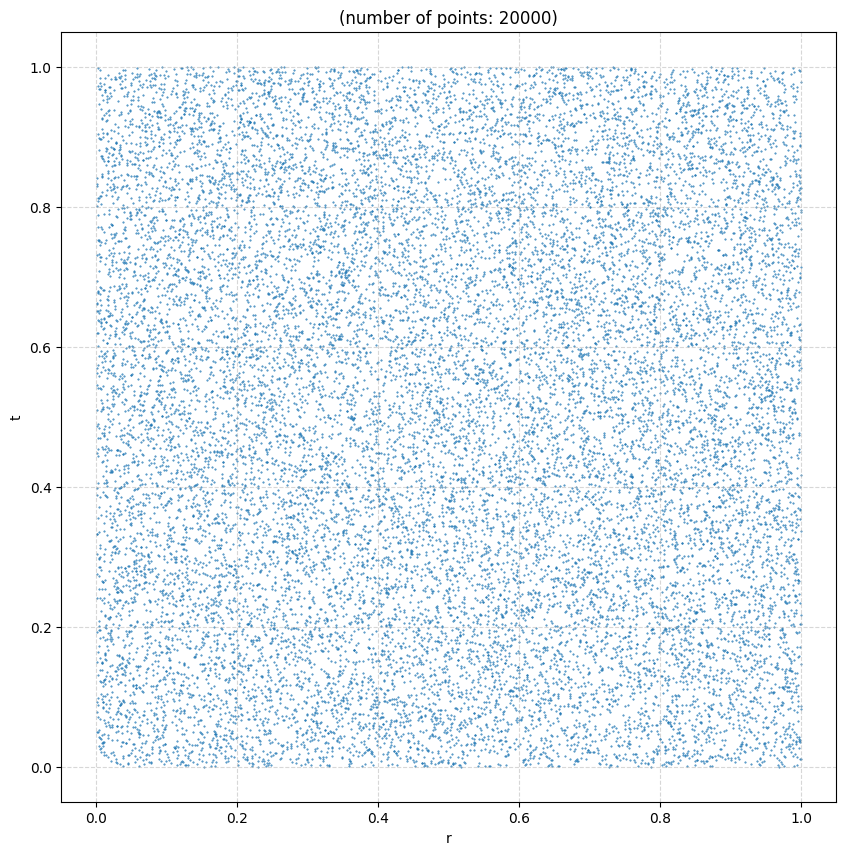

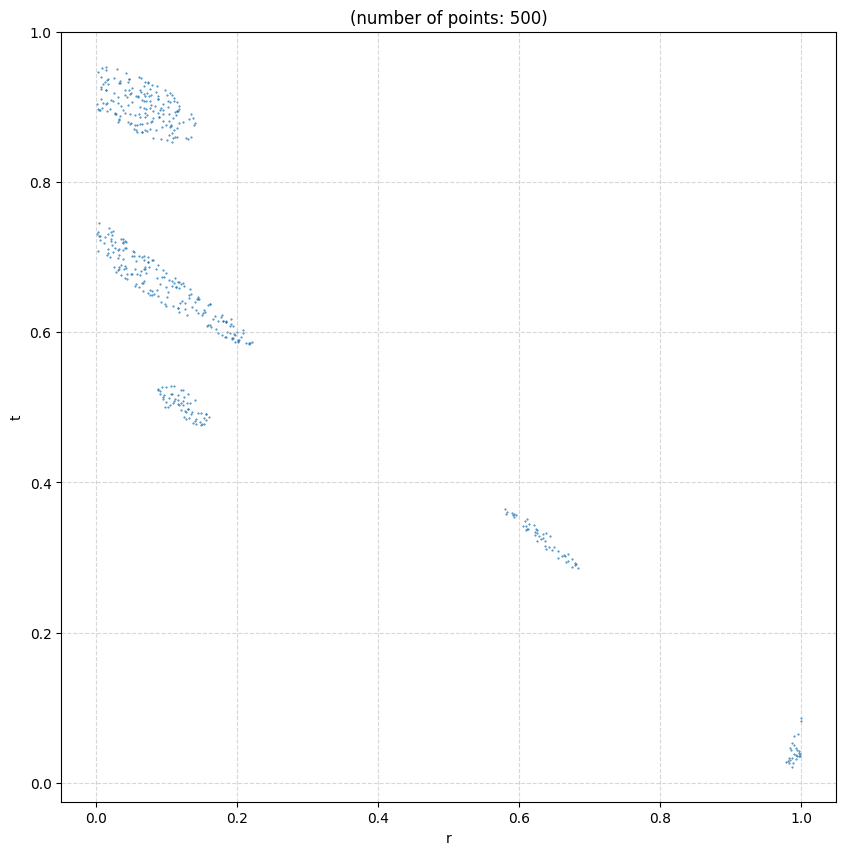

[RAR-G] round  3 | points= 3500 | max_res=1.065e+02 | mean_res=3.450e+01
Adam Training started...
- Epochs: 10000
- R_T: 1060.00
- domain upper boundsNone
--------------------------------------------------------------------------------------------------------------------------------
  Epoch    |   Total    |   pde_0    |   pde_1    |   pde_2    |    bc0     |    bcR     |    ic_0    |    ic_1    |    ic_2    
--------------------------------------------------------------------------------------------------------------------------------
    0      | 3.7436e+00 | 2.7085e-01 | 2.2513e+00 | 6.4327e-05 | 4.2482e-03 | 1.2171e+00 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   200     | 1.4858e+00 | 1.0951e-01 | 1.8248e-01 | 1.4181e-04 | 3.3039e-03 | 1.1903e+00 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   400     | 1.4478e+00 | 1.0308e-01 | 1.5242e-01 | 1.1020e-04 | 3.2633e-03 | 1.1889e+00 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   600     | 1.4283e+00 | 9.8035e-02 | 1.4087e-01 | 9.4334e-05 | 3.2131e-0

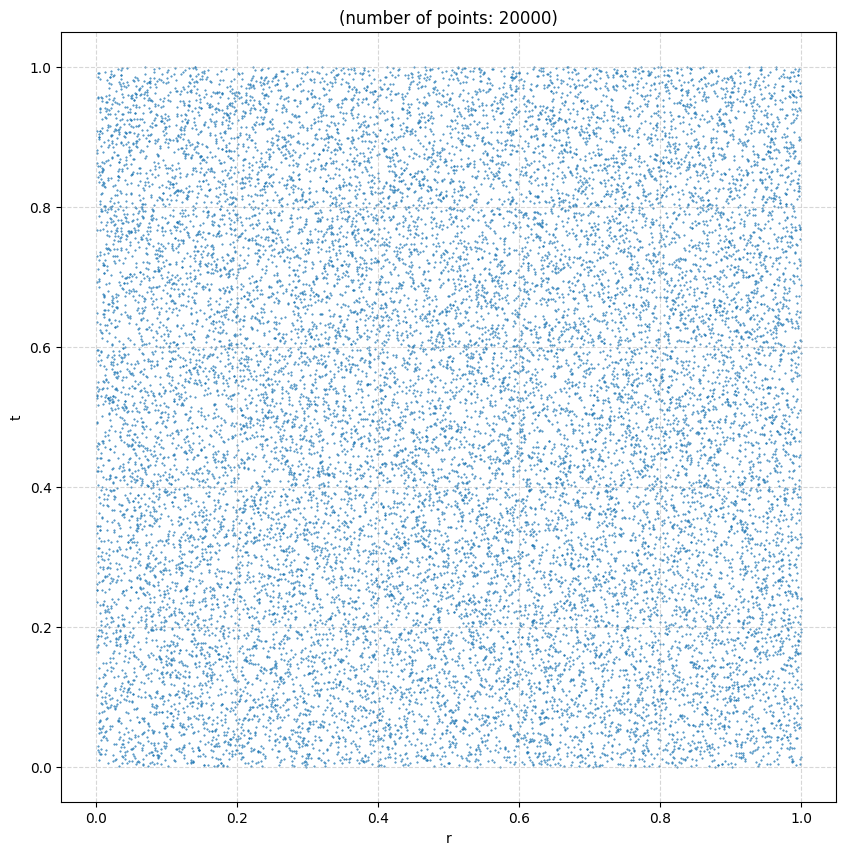

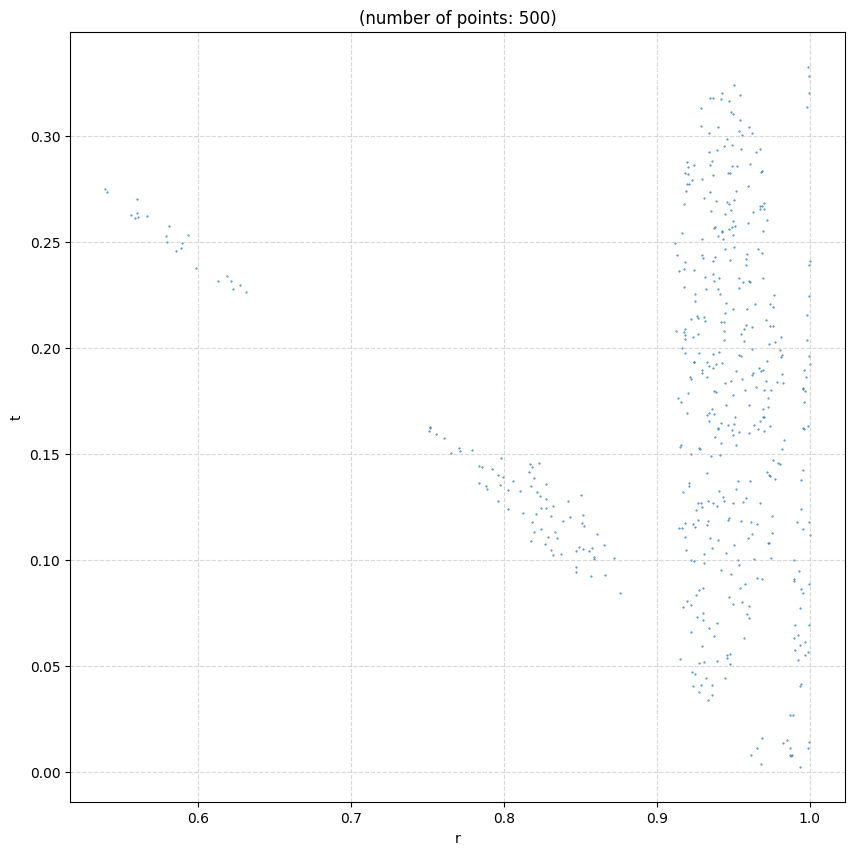

[RAR-G] round  4 | points= 4000 | max_res=1.389e+02 | mean_res=7.645e+00
Adam Training started...
- Epochs: 10000
- R_T: 1060.00
- domain upper boundsNone
--------------------------------------------------------------------------------------------------------------------------------
  Epoch    |   Total    |   pde_0    |   pde_1    |   pde_2    |    bc0     |    bcR     |    ic_0    |    ic_1    |    ic_2    
--------------------------------------------------------------------------------------------------------------------------------
    0      | 9.9373e-01 | 1.0185e-01 | 1.5264e-01 | 4.8384e-05 | 2.2206e-03 | 7.3696e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   200     | 9.4349e-01 | 8.0032e-02 | 1.2557e-01 | 4.8940e-05 | 2.1485e-03 | 7.3570e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   400     | 9.6148e-01 | 8.4969e-02 | 1.4208e-01 | 4.6852e-05 | 2.1032e-03 | 7.3229e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   600     | 2.7164e+00 | 2.5108e-01 | 1.7140e+00 | 4.9594e-05 | 2.0328e-0

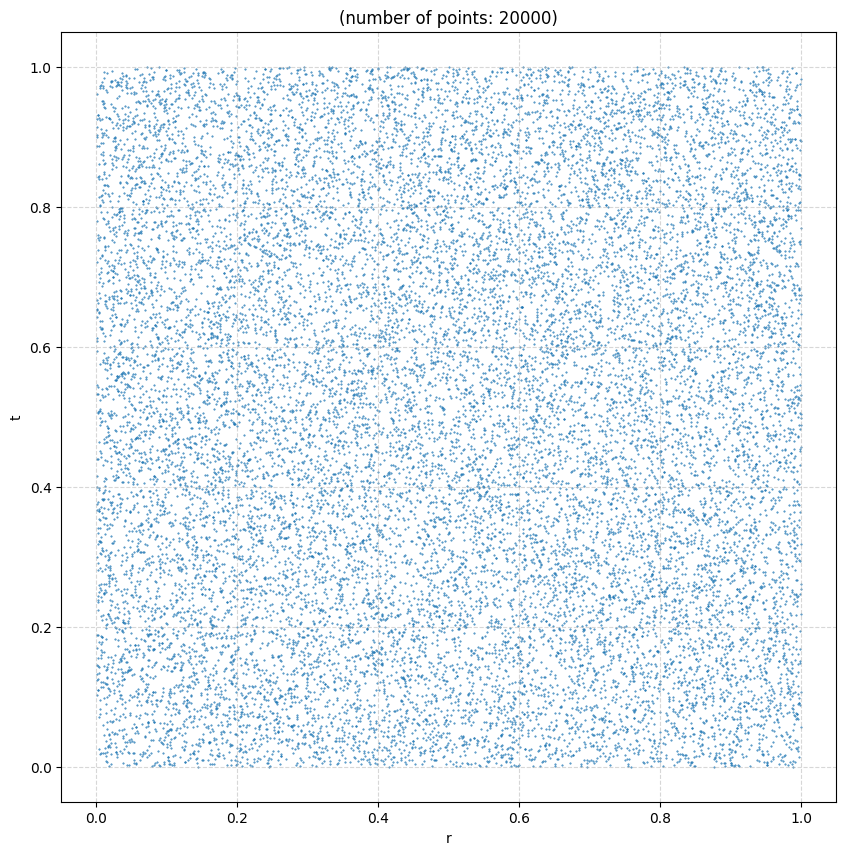

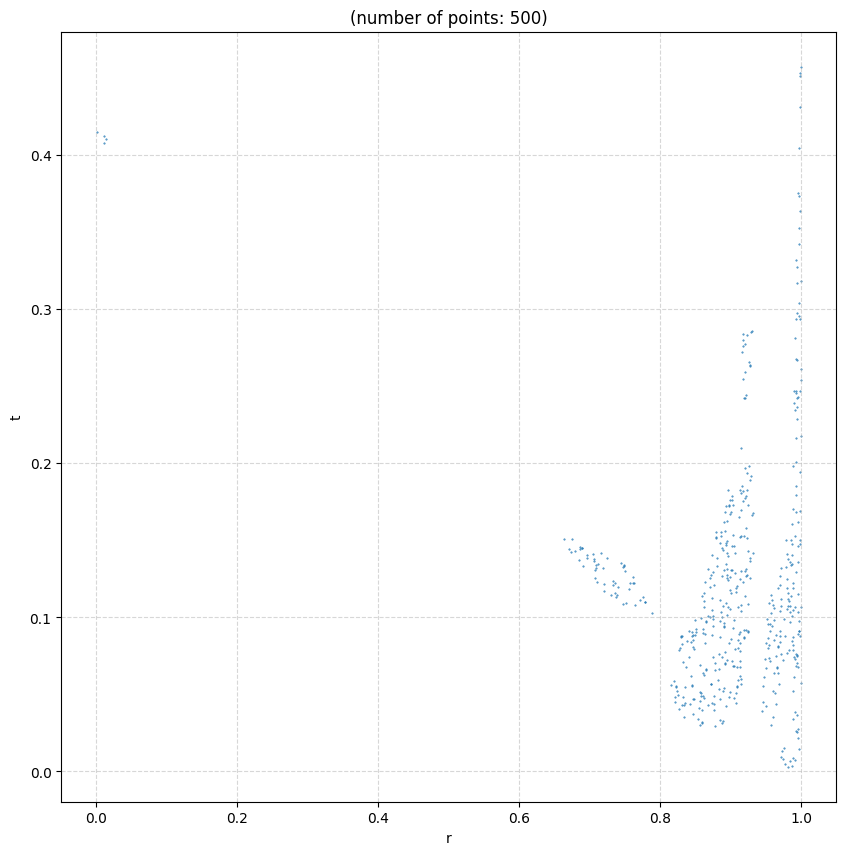

[RAR-G] round  5 | points= 4500 | max_res=2.094e+02 | mean_res=6.321e+00
Adam Training started...
- Epochs: 10000
- R_T: 1060.00
- domain upper boundsNone
--------------------------------------------------------------------------------------------------------------------------------
  Epoch    |   Total    |   pde_0    |   pde_1    |   pde_2    |    bc0     |    bcR     |    ic_0    |    ic_1    |    ic_2    
--------------------------------------------------------------------------------------------------------------------------------
    0      | 8.6032e-01 | 1.0751e-01 | 8.9685e-02 | 7.7673e-06 | 1.5725e-03 | 6.6154e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   200     | 8.5379e-01 | 9.8083e-02 | 9.0311e-02 | 7.4954e-06 | 1.5437e-03 | 6.6385e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   400     | 8.5193e-01 | 9.6105e-02 | 9.1289e-02 | 7.1113e-06 | 1.5352e-03 | 6.6299e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   600     | 9.5276e-01 | 1.1146e-01 | 1.7615e-01 | 7.8234e-06 | 1.4427e-0

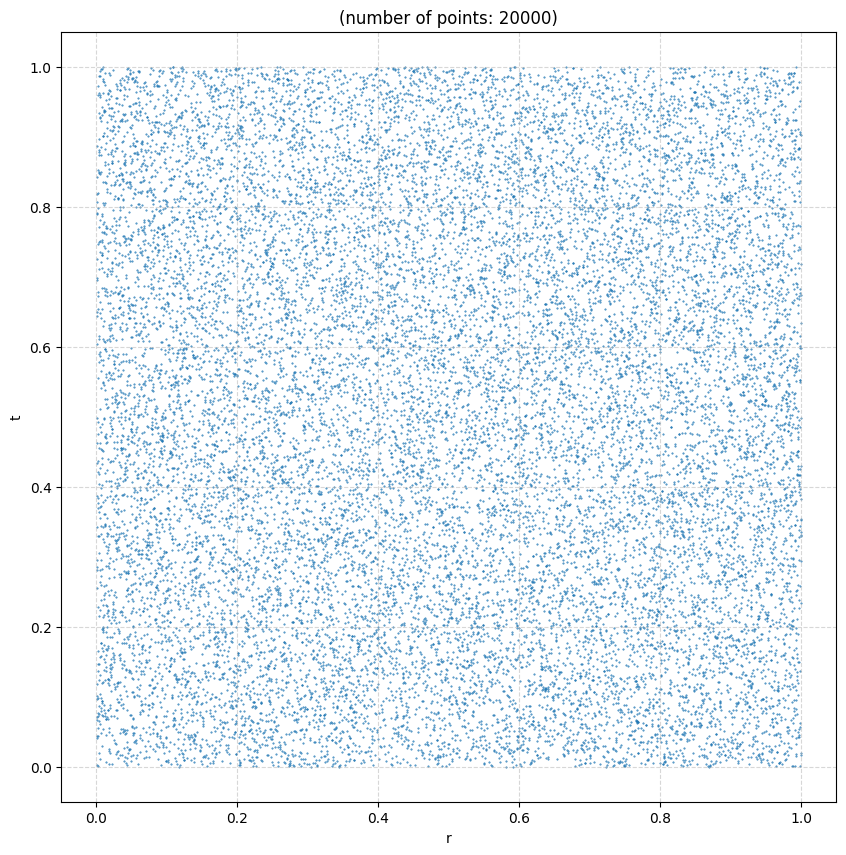

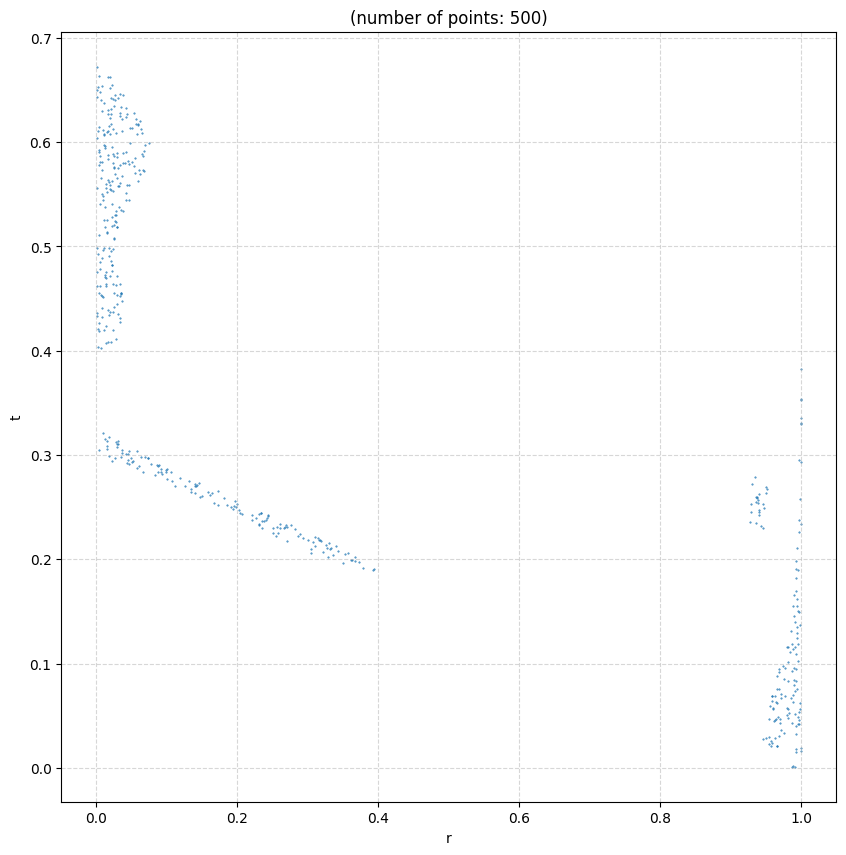

[RAR-G] round  6 | points= 5000 | max_res=2.143e+02 | mean_res=8.307e+00
Adam Training started...
- Epochs: 10000
- R_T: 1060.00
- domain upper boundsNone
--------------------------------------------------------------------------------------------------------------------------------
  Epoch    |   Total    |   pde_0    |   pde_1    |   pde_2    |    bc0     |    bcR     |    ic_0    |    ic_1    |    ic_2    
--------------------------------------------------------------------------------------------------------------------------------
    0      | 8.6144e-01 | 9.0743e-02 | 1.3692e-01 | 6.6134e-06 | 1.2865e-03 | 6.3249e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   200     | 3.5199e+00 | 2.8598e-01 | 2.5180e+00 | 6.3391e-06 | 1.2463e-03 | 7.1462e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   400     | 8.4095e-01 | 9.2351e-02 | 1.1133e-01 | 5.7860e-06 | 1.2508e-03 | 6.3602e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   600     | 8.1154e-01 | 8.5677e-02 | 9.0536e-02 | 5.6853e-06 | 1.2304e-0

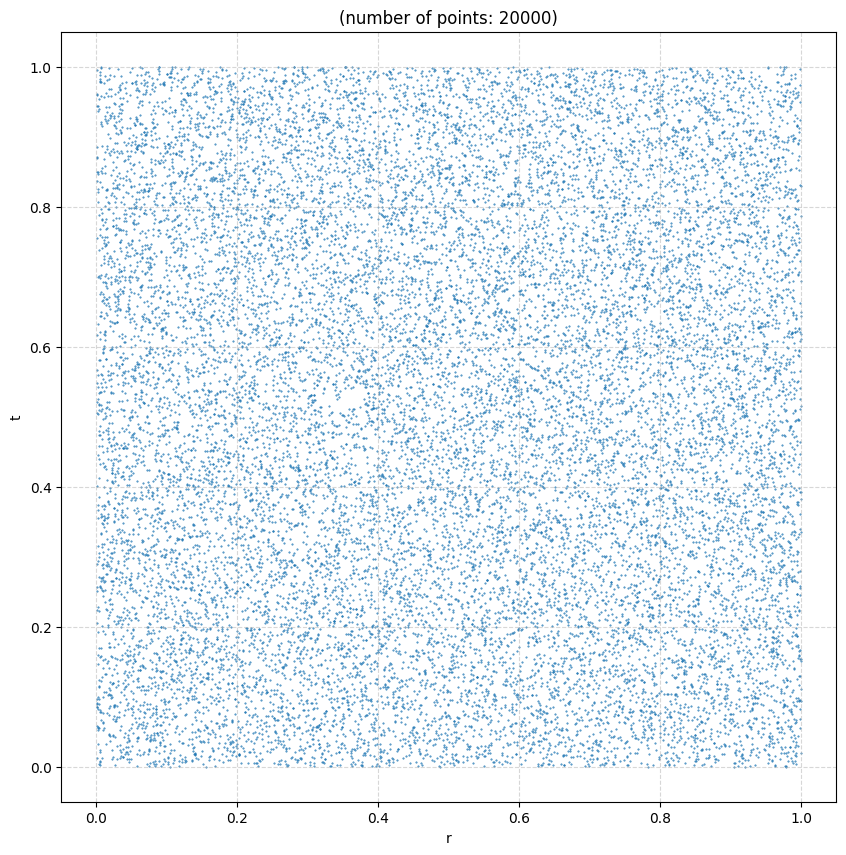

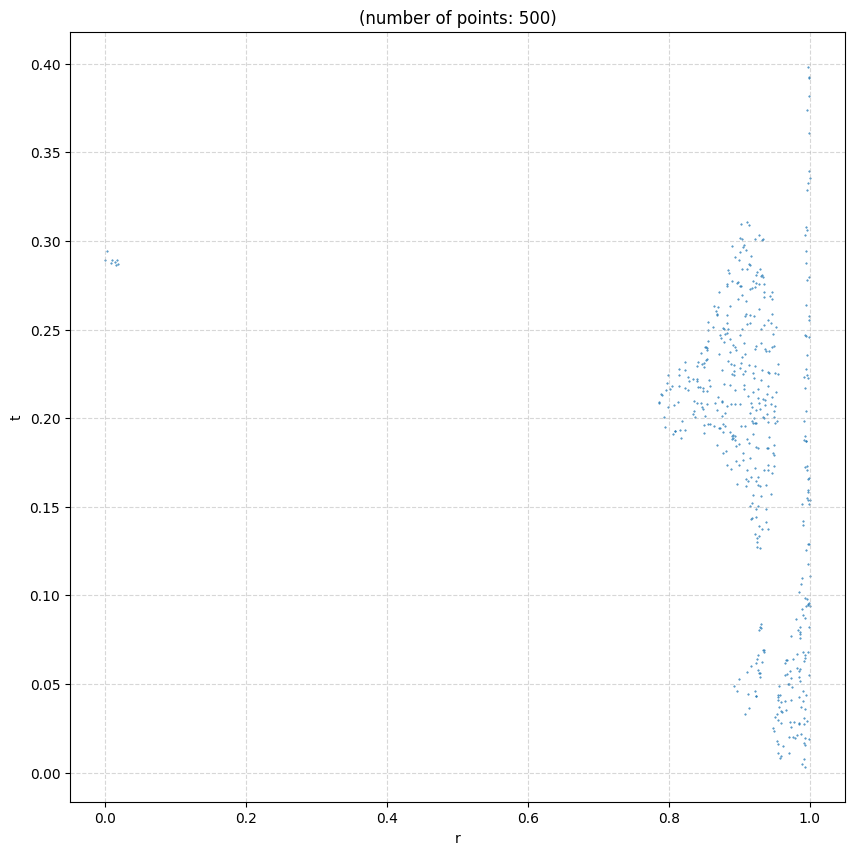

[RAR-G] round  7 | points= 5500 | max_res=1.238e+02 | mean_res=5.559e+00
Adam Training started...
- Epochs: 10000
- R_T: 1060.00
- domain upper boundsNone
--------------------------------------------------------------------------------------------------------------------------------
  Epoch    |   Total    |   pde_0    |   pde_1    |   pde_2    |    bc0     |    bcR     |    ic_0    |    ic_1    |    ic_2    
--------------------------------------------------------------------------------------------------------------------------------
    0      | 7.7069e-01 | 7.4165e-02 | 8.8198e-02 | 4.9766e-06 | 1.1909e-03 | 6.0713e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   200     | 7.6828e-01 | 7.1049e-02 | 8.8795e-02 | 4.7594e-06 | 1.2137e-03 | 6.0721e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   400     | 7.6585e-01 | 6.9996e-02 | 8.8612e-02 | 4.7359e-06 | 1.2291e-03 | 6.0601e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   600     | 7.6188e-01 | 6.9291e-02 | 8.8882e-02 | 4.7624e-06 | 1.2214e-0

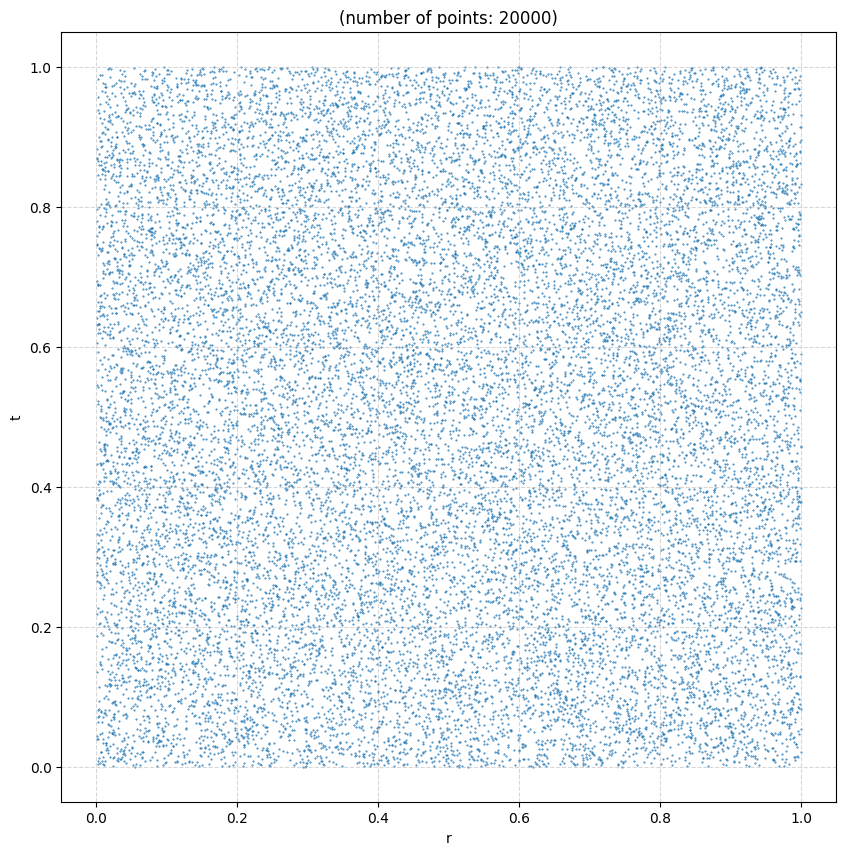

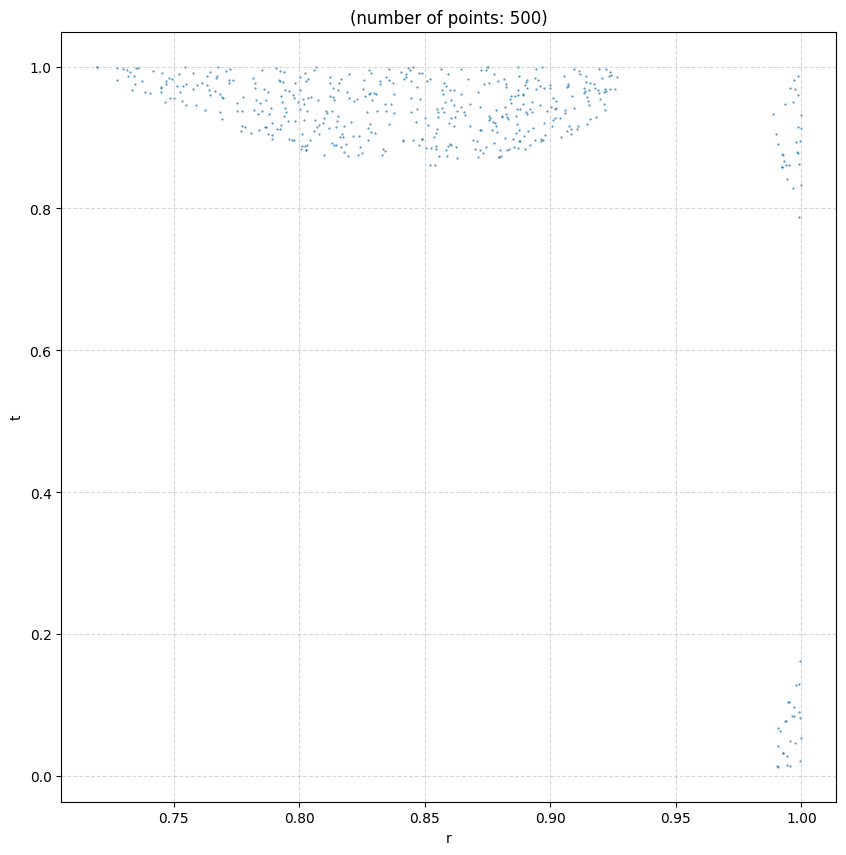

[RAR-G] round  8 | points= 6000 | max_res=9.279e+01 | mean_res=1.118e+01
Adam Training started...
- Epochs: 10000
- R_T: 1060.00
- domain upper boundsNone
--------------------------------------------------------------------------------------------------------------------------------
  Epoch    |   Total    |   pde_0    |   pde_1    |   pde_2    |    bc0     |    bcR     |    ic_0    |    ic_1    |    ic_2    
--------------------------------------------------------------------------------------------------------------------------------
    0      | 9.0606e-01 | 7.7453e-02 | 2.2872e-01 | 8.8059e-06 | 1.1490e-03 | 5.9873e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   200     | 7.5771e-01 | 5.7508e-02 | 1.0684e-01 | 2.5545e-05 | 4.5260e-04 | 5.9288e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   400     | 7.5021e-01 | 5.6892e-02 | 1.0020e-01 | 2.1207e-05 | 4.5834e-04 | 5.9264e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   600     | 7.4610e-01 | 5.6818e-02 | 9.6305e-02 | 1.8403e-05 | 4.6446e-0

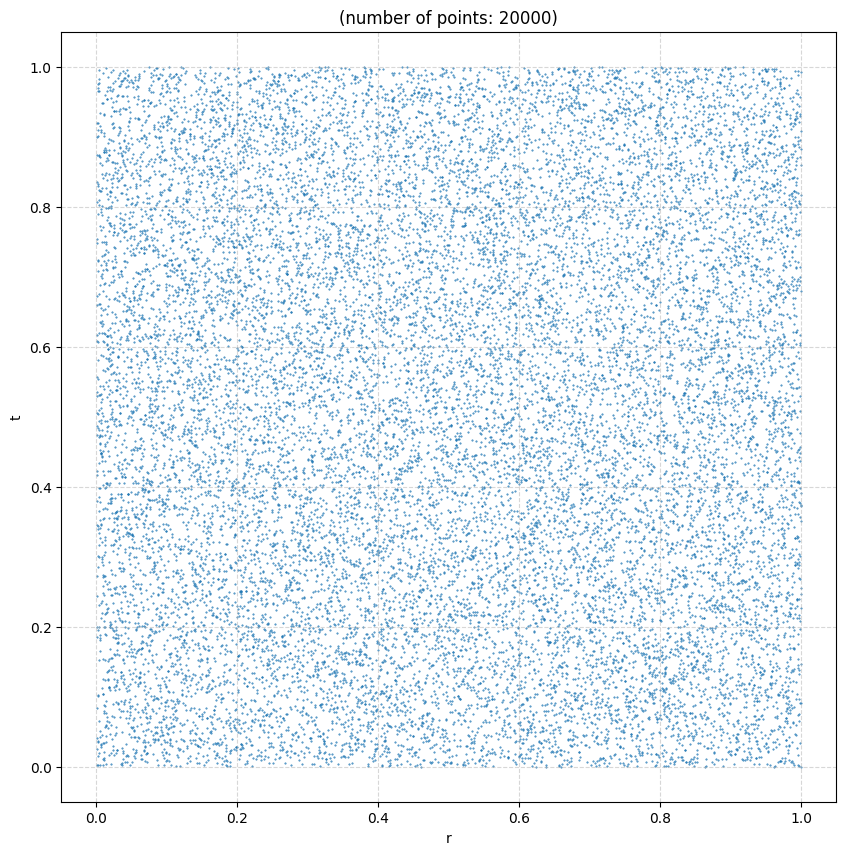

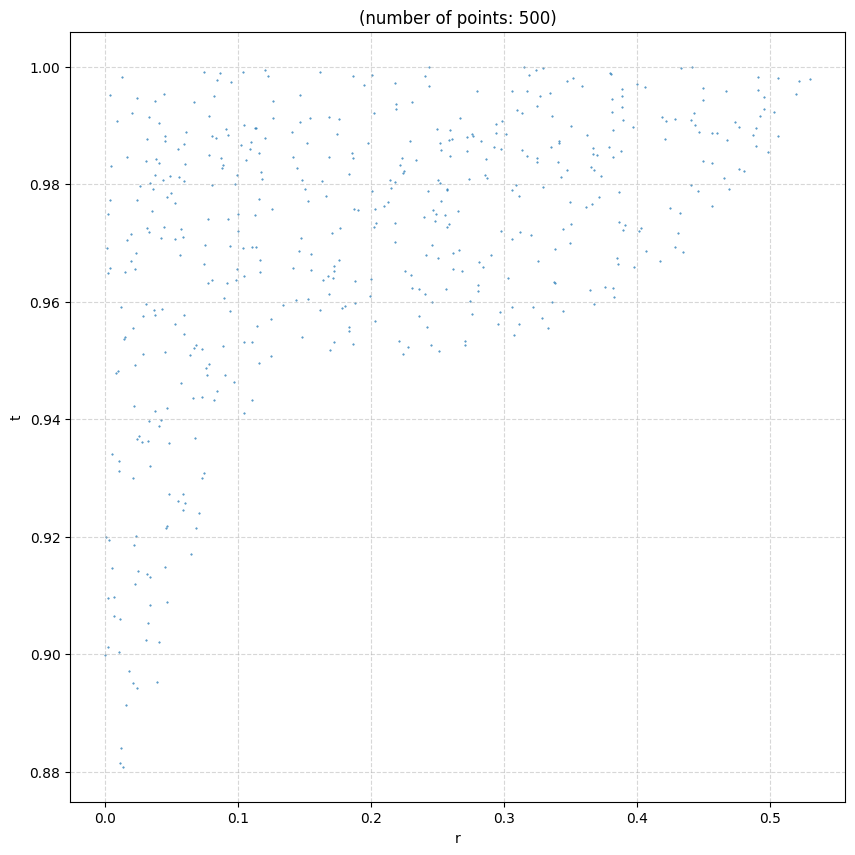

[RAR-G] round  9 | points= 6500 | max_res=1.165e+02 | mean_res=6.631e+01
Adam Training started...
- Epochs: 10000
- R_T: 1060.00
- domain upper boundsNone
--------------------------------------------------------------------------------------------------------------------------------
  Epoch    |   Total    |   pde_0    |   pde_1    |   pde_2    |    bc0     |    bcR     |    ic_0    |    ic_1    |    ic_2    
--------------------------------------------------------------------------------------------------------------------------------
    0      | 6.6383e+00 | 4.9728e-01 | 5.5102e+00 | 6.6293e-06 | 8.5552e-04 | 6.2995e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   200     | 7.2030e-01 | 4.6553e-02 | 8.4905e-02 | 7.9585e-06 | 5.4427e-04 | 5.8829e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   400     | 7.1715e-01 | 4.7045e-02 | 8.1456e-02 | 6.9670e-06 | 5.6014e-04 | 5.8809e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   600     | 7.1533e-01 | 4.7109e-02 | 7.9624e-02 | 6.8554e-06 | 5.7828e-0

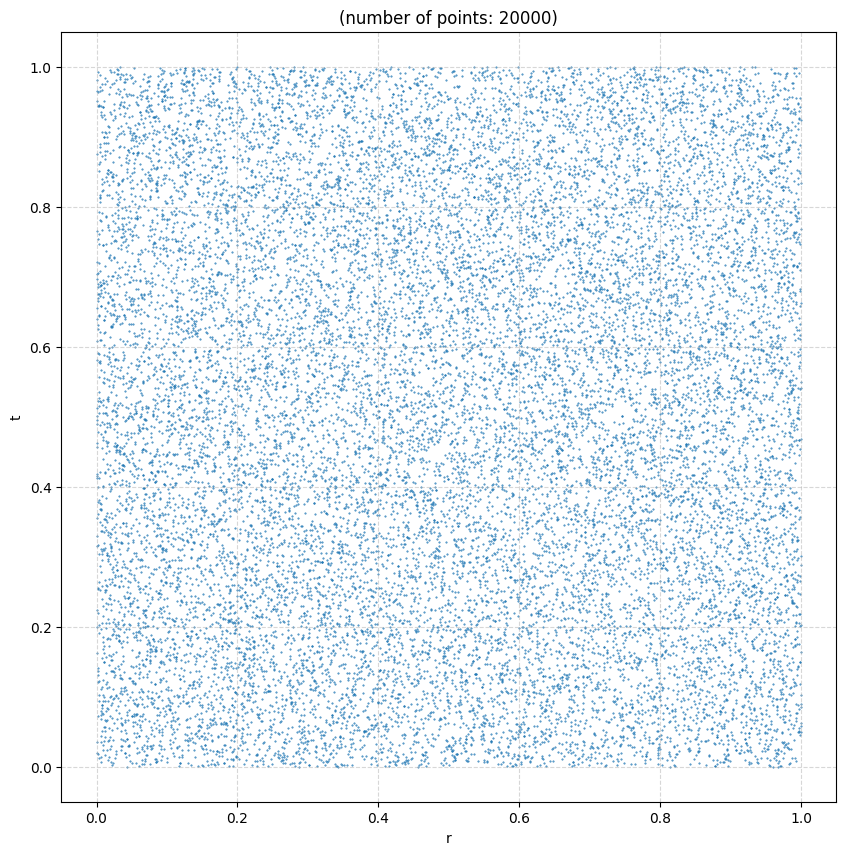

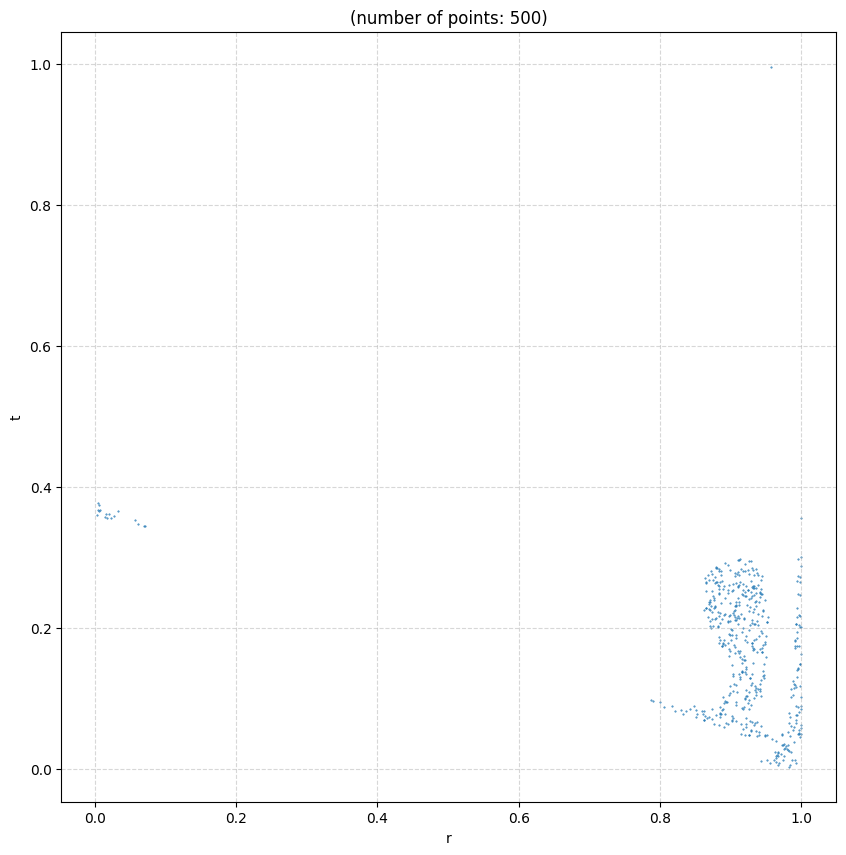

[RAR-G] round 10 | points= 7000 | max_res=5.862e+01 | mean_res=5.542e+00
Adam Training started...
- Epochs: 10000
- R_T: 1060.00
- domain upper boundsNone
--------------------------------------------------------------------------------------------------------------------------------
  Epoch    |   Total    |   pde_0    |   pde_1    |   pde_2    |    bc0     |    bcR     |    ic_0    |    ic_1    |    ic_2    
--------------------------------------------------------------------------------------------------------------------------------
    0      | 7.1647e-01 | 4.7531e-02 | 8.1953e-02 | 5.7053e-06 | 1.0359e-03 | 5.8594e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   200     | 1.0316e+01 | 1.0506e+00 | 8.6311e+00 | 6.4590e-06 | 1.0677e-03 | 6.3343e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   400     | 7.1386e-01 | 4.8034e-02 | 7.8741e-02 | 5.5934e-06 | 1.1439e-03 | 5.8594e-01 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00
   600     | 7.1412e-01 | 4.7939e-02 | 7.9178e-02 | 5.5936e-06 | 1.0698e-0

In [1]:
import torch
from trastuzumab import pinns, residuals, neural_nets, datasets, sampling

pinn = pinns.Pinn(n_col=2000, n_initial=200, n_center=200, n_surface=200, u_bounds=[1, 1], device='cpu', layers=3, neurons=64)
optimizer = torch.optim.Adam(pinn.net.parameters(), 0.001)

log = sampling.rar_g(pinn, optimizer=optimizer, n_rounds=3, rnd_epochs=10000, point_budget=10000)
print(log)
pinns.get_spatial_antibody_distribution(1.0, pinn, 1.0)

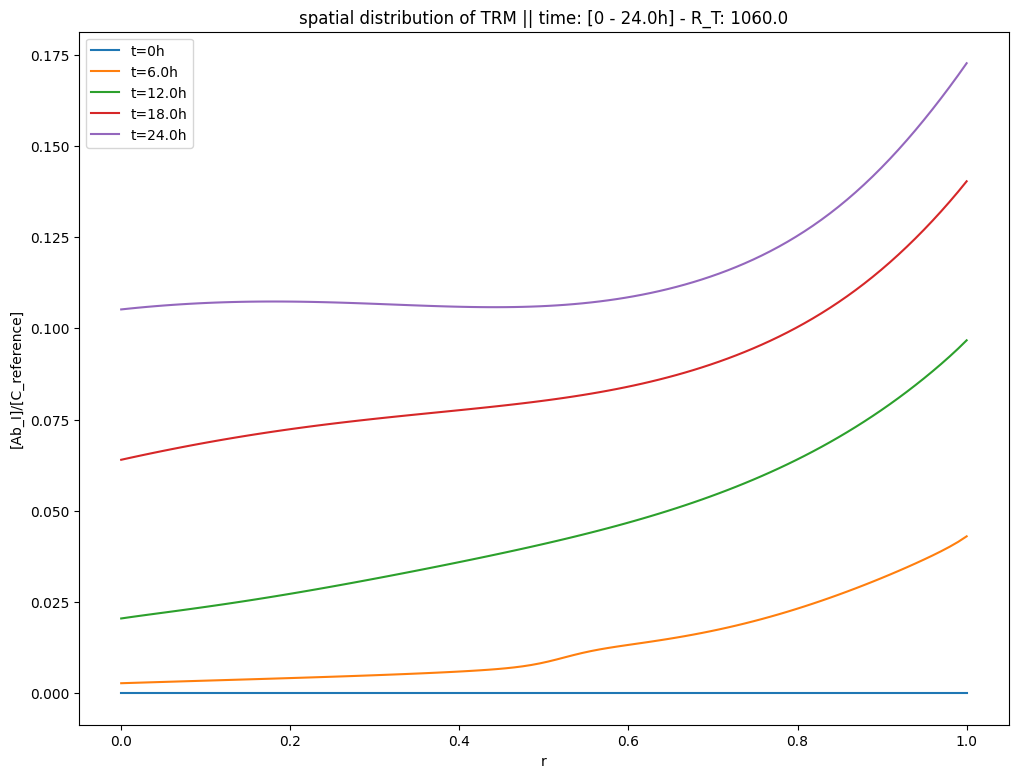

[{'round': 1,
  'n_points': 2500,
  'max_score': 270.33648681640625,
  'mean_score': 99.6635971069336},
 {'round': 2,
  'n_points': 3000,
  'max_score': 68.17036437988281,
  'mean_score': 27.617006301879883},
 {'round': 3,
  'n_points': 3500,
  'max_score': 106.5093765258789,
  'mean_score': 34.5037956237793},
 {'round': 4,
  'n_points': 4000,
  'max_score': 138.86082458496094,
  'mean_score': 7.6448187828063965},
 {'round': 5,
  'n_points': 4500,
  'max_score': 209.3900909423828,
  'mean_score': 6.321378707885742},
 {'round': 6,
  'n_points': 5000,
  'max_score': 214.28353881835938,
  'mean_score': 8.307270050048828},
 {'round': 7,
  'n_points': 5500,
  'max_score': 123.76412200927734,
  'mean_score': 5.559060096740723},
 {'round': 8,
  'n_points': 6000,
  'max_score': 92.79376220703125,
  'mean_score': 11.18481731414795},
 {'round': 9,
  'n_points': 6500,
  'max_score': 116.4757308959961,
  'mean_score': 66.30731201171875},
 {'round': 10,
  'n_points': 7000,
  'max_score': 58.6231460

In [4]:
pinns.get_spatial_antibody_distribution(1.0, pinn, 1.0)
log